# Q1 Momentum Backtester Framework  
###   *by Dr. W. Vera-Tudela*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns


import sys
sys.path.append('../utils')   # path relative to the notebook
from Q1_functions import add_signals, run_backtest, compute_metrics, plot_performance
from common import fetch_data

In [37]:
# Load data
starting_capital = 1_000_000
period = 10
end = pd.Timestamp.today(tz="UTC").normalize()
start = end - pd.DateOffset(years=period)

ticker = 'CRM' # ['AAPL', 'AXP', 'BAC', 'BTC-EUR', 'CRM', 'CVX', 'IBM', 'KO', 'MA', 'MCO', 'MSFT', 'NVDA', 'ORCL', 'PEP', 'PG', 'RACE.MI', 'TSM', 'V']
data = fetch_data(ticker, start, end)
data = add_signals(data)

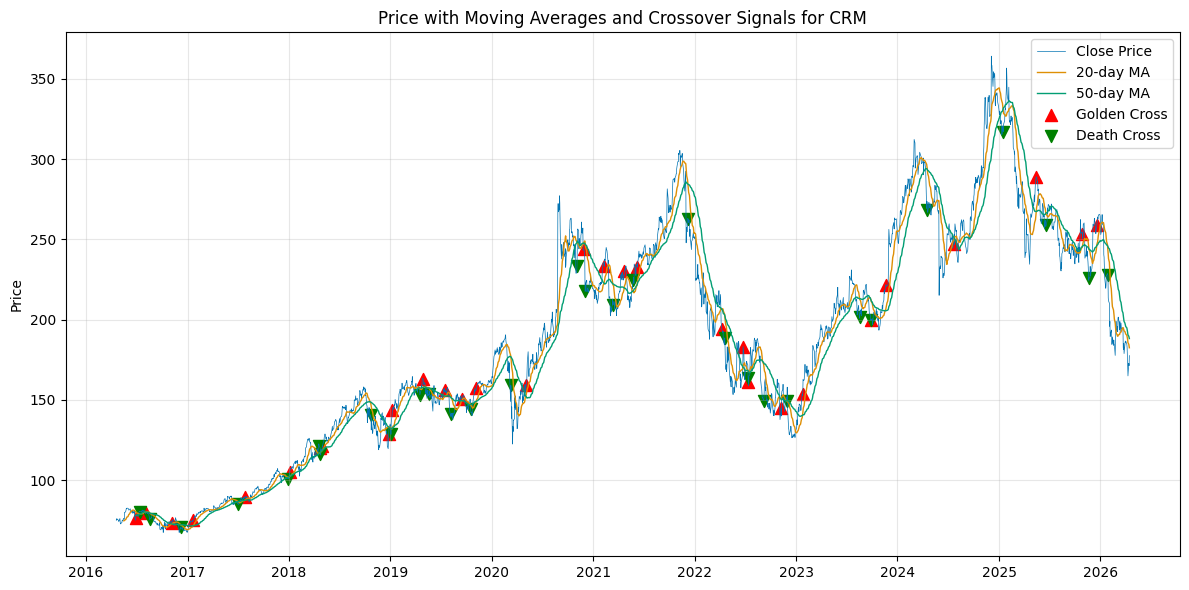

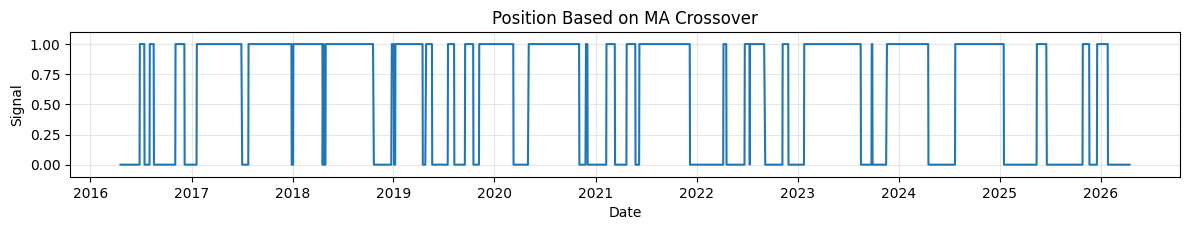

In [38]:
# Visualize the signals to check that the MA and crosses are calöculated correctly
plt.figure(figsize=(12, 6))
colors = sns.color_palette("colorblind")

plt.plot(data.index, data['Close'], color=colors[0], label='Close Price', linewidth=0.5)
plt.plot(data.index, data['MA20'], color=colors[1], label='20-day MA', linewidth=1, linestyle='-')
plt.plot(data.index, data['MA50'], color=colors[2], label='50-day MA', linewidth=1, linestyle='-')

golden_cross_points = data[data['Golden_Cross']]
death_cross_points = data[data['Death_Cross']]
plt.scatter(golden_cross_points.index, golden_cross_points['Close'], color='red', s=75, marker='^', label='Golden Cross')
plt.scatter(death_cross_points.index, death_cross_points['Close'], color='green', s=75, marker='v', label='Death Cross')

plt.title(f'Price with Moving Averages and Crossover Signals for {ticker}')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
colors = sns.color_palette("colorblind")
plt.subplot(2, 1, 2)
plt.plot(data.index, data['Signal'], label='Position (1=Long, 0=Cash)')

plt.title('Position Based on MA Crossover')
plt.xlabel('Date')
plt.ylabel('Signal')
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

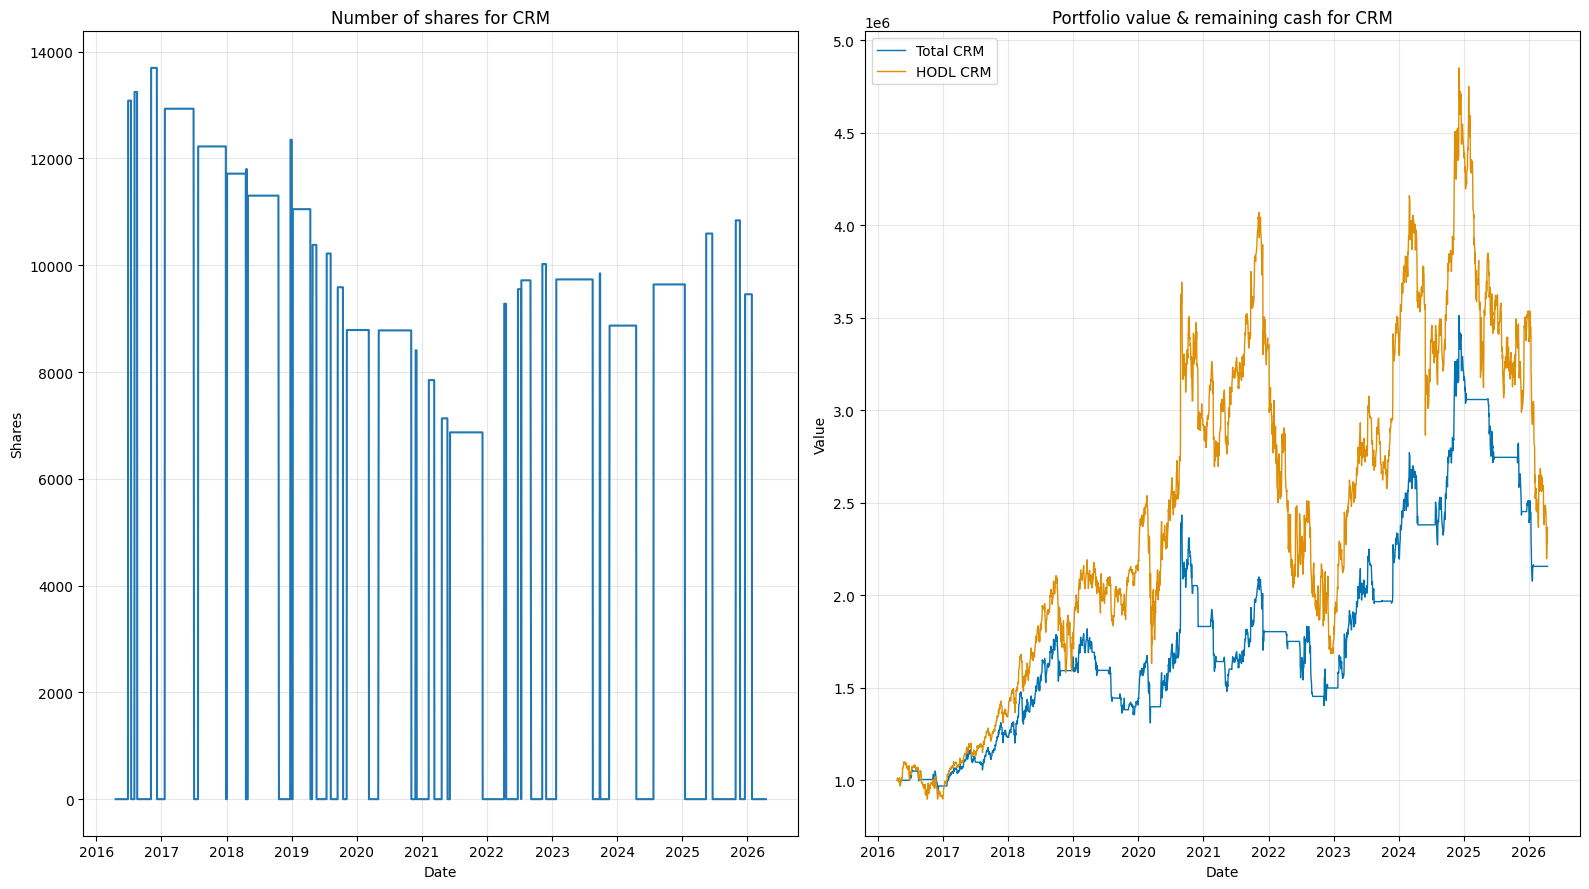

Total:     2,156,000
Buy_Hold:  2,365,238


In [39]:
data = run_backtest(data, starting_capital, tranche=False)

plt.figure(figsize=(16, 9))
colors = sns.color_palette("colorblind")

plt.subplot(1, 2, 1)
plt.title(f'Number of shares for {ticker}')
plt.plot(data.index, data['Shares'], label='Close Price')
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Shares')

plt.subplot(1, 2, 2)
plt.title(f'Portfolio value & remaining cash for {ticker}')
plt.plot(data.index, data['Total'], color=colors[0], label=f'Total {ticker}', linewidth=1)
plt.plot(data.index, data['Buy_Hold'], color=colors[1], label=f'HODL {ticker}', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Total:     {data.iloc[-1]['Total']:,.0f}")
print(f"Buy_Hold:  {data.iloc[-1]['Buy_Hold']:,.0f}")

In [40]:
data, table, yearly_data = compute_metrics(data, starting_capital)
display(table)

,Buy Sell,Buy Hold
Total Return,1.156000,1.365238
Sharpe,0.157434,0.133234
Max Drawdown,-0.423339,-0.586172
CAGR,0.079956,0.090018
Calmar,-0.188870,-0.153569
Win Rate,0.466667,1.000000


In [41]:
def run_ma_strategy(df, starting_capital, fast, slow):
    df = df.copy()
    
    # Moving averages
    df['MA_fast'] = df['Close'].rolling(fast).mean()
    df['MA_slow'] = df['Close'].rolling(slow).mean()
    
    # Signals
    df['Golden_Cross'] = (df['MA_fast'] > df['MA_slow']) & (df['MA_fast'].shift(1) <= df['MA_slow'].shift(1))
    df['Death_Cross']  = (df['MA_fast'] < df['MA_slow']) & (df['MA_fast'].shift(1) >= df['MA_slow'].shift(1))
    
    # Drop initial NaNs
    df = df.dropna().copy()
    
    df['Cash'] = 0.0
    df['Portfolio_Value'] = 0.0
    df['Shares'] = 0.0
    
    cash = starting_capital
    shares = 0.0
    
    for idx, row in df.iterrows():
        price = row['Close']
        port_val = shares * price
        
        if row['Golden_Cross']:
            shares = cash / price # fractional trading
            port_val = shares * price
            cash -= port_val
            
        if row['Death_Cross']:
            cash += shares * price
            shares = 0
            port_val = 0

        df.loc[idx, 'Cash'] = cash
        df.loc[idx, 'Portfolio_Value'] = port_val
        df.loc[idx, 'Shares'] = shares
    
    df['Total'] = df['Portfolio_Value'] + df['Cash']
    final_total = df['Total'].iloc[-1]

    return final_total

In [50]:
def optimize_ma(df_train, starting_capital):
    
    df = df_train.copy()
    
    fast_range = range(5, 50, 5)      # 5,10,...,55
    slow_range = range(60, 210, 10)   # 20,30,...,200
    
    results = []
    
    for fast in fast_range:
        for slow in slow_range:
            if fast >= slow:
                continue  # fast must be < slow
            final_total = run_ma_strategy(df, starting_capital, fast, slow)
            results.append((fast, slow, final_total))
    
    # Find best
    best_fast, best_slow, best_total = max(results, key=lambda x: x[2])
    
    print(f"Best fast: {best_fast}, best slow: {best_slow}, final: {best_total:,.0f}")

    return best_fast, best_slow, best_total

In [51]:
df = data.copy()
split_idx = int(len(df) * 0.7)

df_train = df.iloc[:split_idx].copy()
df_test  = df.iloc[split_idx:].copy()

In [52]:
# 1. Optimize on training set
best_fast, best_slow, best_total = optimize_ma(df_train, starting_capital)

print("Best parameters on training:")
print(best_fast, best_slow)

Best fast: 40, best slow: 70, final: 2,595,945
Best parameters on training:
40 70


In [53]:
# 2. Test on unseen data
test_total = run_ma_strategy(df_test, starting_capital, best_fast, best_slow)

print(f"Out-of-sample result: {test_total:,.0f}")

Out-of-sample result: 861,732


In [54]:
data_test = data.iloc[split_idx-best_slow:].copy()

data_test = add_signals(data_test, best_fast, best_slow)
data_test = run_backtest(data_test, starting_capital)

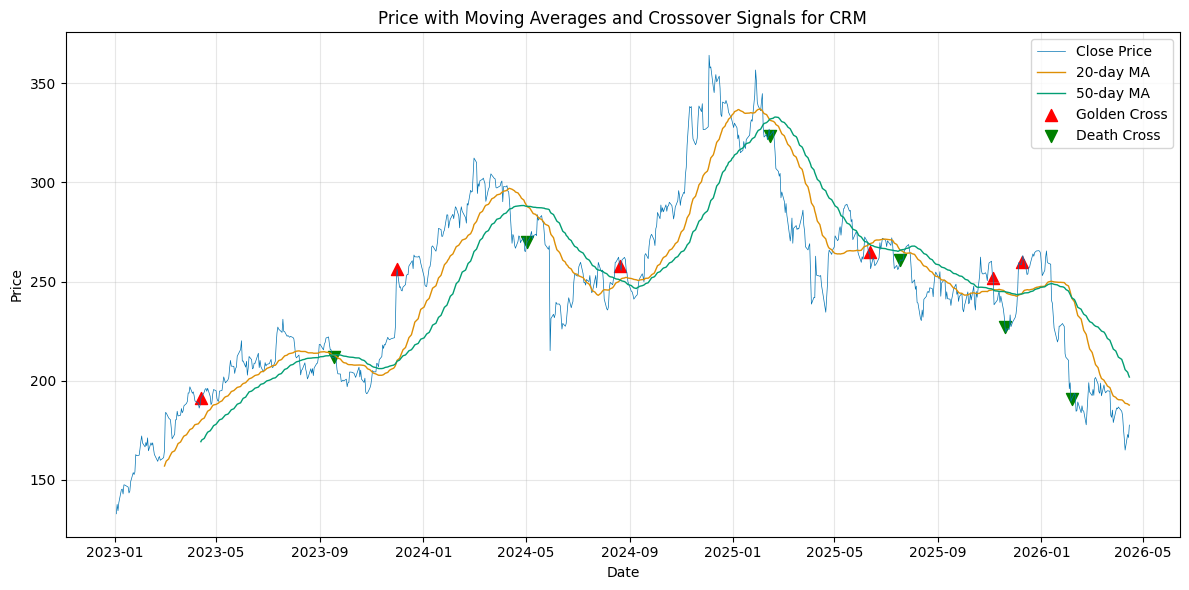

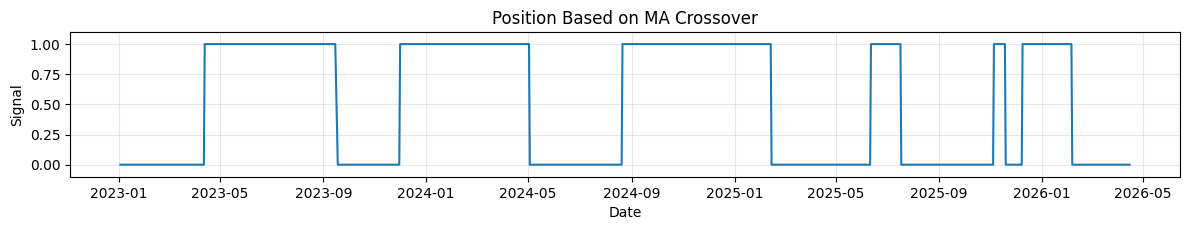

In [55]:
# Visualize the signals to check that the MA and crosses are calöculated correctly
plt.figure(figsize=(12, 6))
colors = sns.color_palette("colorblind")

plt.plot(data_test.index, data_test['Close'], color=colors[0], label='Close Price', linewidth=0.5)
plt.plot(data_test.index, data_test['MA20'], color=colors[1], label='20-day MA', linewidth=1, linestyle='-')
plt.plot(data_test.index, data_test['MA50'], color=colors[2], label='50-day MA', linewidth=1, linestyle='-')

golden_cross_points = data_test[data_test['Golden_Cross']]
death_cross_points = data_test[data_test['Death_Cross']]
plt.scatter(golden_cross_points.index, golden_cross_points['Close'], color='red', s=75, marker='^', label='Golden Cross')
plt.scatter(death_cross_points.index, death_cross_points['Close'], color='green', s=75, marker='v', label='Death Cross')

plt.title(f'Price with Moving Averages and Crossover Signals for {ticker}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
colors = sns.color_palette("colorblind")
plt.subplot(2, 1, 2)
plt.plot(data_test.index, data_test['Signal'], label='Position (1=Long, 0=Cash)')

plt.title('Position Based on MA Crossover')
plt.xlabel('Date')
plt.ylabel('Signal')
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

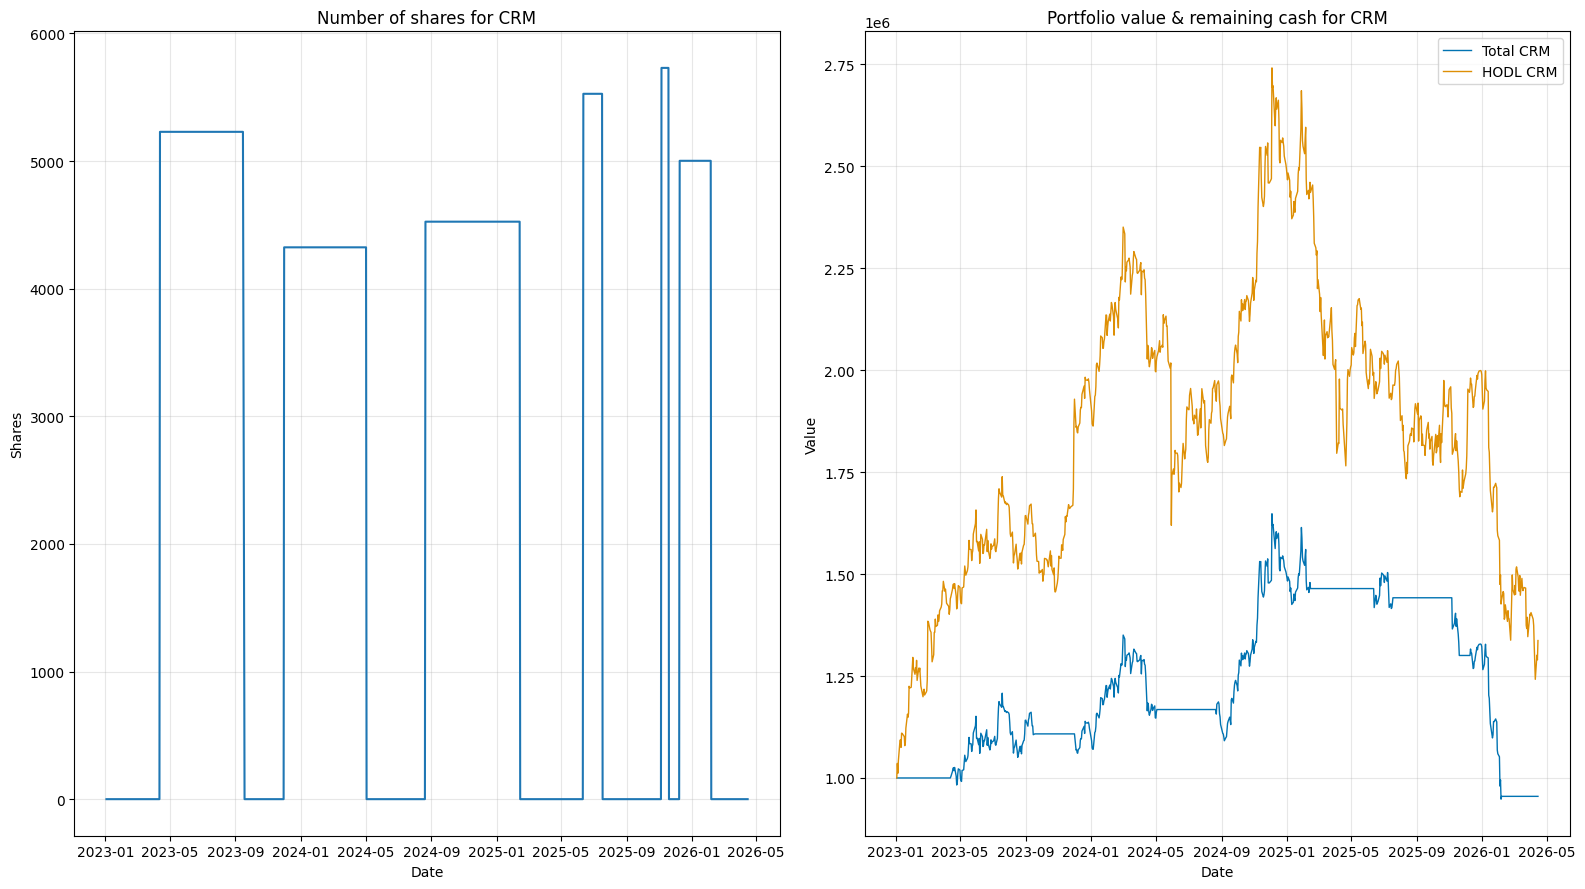

Total:    $ 954,914
Buy_Hold: $ 1,337,049


In [56]:
plt.figure(figsize=(16, 9))
colors = sns.color_palette("colorblind")

plt.subplot(1, 2, 1)
plt.title(f'Number of shares for {ticker}')
plt.plot(data_test.index, data_test['Shares'], label='Close Price')
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Shares')

plt.subplot(1, 2, 2)
plt.title(f'Portfolio value & remaining cash for {ticker}')
plt.plot(data_test.index, data_test['Total'], color=colors[0], label=f'Total {ticker}', linewidth=1)
plt.plot(data_test.index, data_test['Buy_Hold'], color=colors[1], label=f'HODL {ticker}', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Total:    $ {data_test.iloc[-1]['Total']:,.0f}")
print(f"Buy_Hold: $ {data_test.iloc[-1]['Buy_Hold']:,.0f}")

In [57]:
window_train = 3 * 365
window_test  = 1 * 365

results = []

start = 0
end = window_train

train_end = train_start + pd.DateOffset(years=5)
test_end  = train_end + pd.DateOffset(years=1)


while end + window_test < len(df):

    df_train = df.iloc[start:end].copy()
    df_test  = df.iloc[end:end + window_test].copy()

    # Optimize on training window
    best_fast, best_slow, best_total = optimize_ma(df_train, starting_capital)
    print(f"Best fast: {best_fast}, best slow: {best_slow}, final: {best_total:,.0f}")
    
    # Test on next window
    test_total = run_ma_strategy(df_test, starting_capital, best_fast, best_slow)
    print(f"Out-of-sample result: {test_total:,.0f}")

    results.append({
        'train_start': df_train.index[0],
        'train_end': df_train.index[-1],
        'test_start': df_test.index[0],
        'test_end': df_test.index[-1],
        'fast': best_fast,
        'slow': best_slow,
        'test_total': test_total
    })

    # Slide window forward by 1 year
    start += window_test
    end   += window_test

# Print results
for r in results:
    print(r)

NameError: name 'train_start' is not defined

In [ ]:
from pandas.tseries.offsets import DateOffset

def slice_by_dates(df, start_date, end_date):
    return df.loc[(df.index >= start_date) & (df.index <= end_date)].copy()


In [ ]:
def walk_forward_validation(df, starting_capital, train_years=5, test_years=1):
    df = df.copy()
    results = []

    # Ensure datetime index
    df.index = pd.to_datetime(df.index)

    # Start at the beginning of the dataset
    current_train_start = df.index.min()

    while True:
        # Define training and testing windows
        train_end = current_train_start + DateOffset(years=train_years)
        test_end  = train_end + DateOffset(years=test_years)

        # Stop if test_end exceeds dataset
        if test_end > df.index.max():
            break

        # Slice windows
        df_train = slice_by_dates(df, current_train_start, train_end)
        df_test  = slice_by_dates(df, train_end + pd.Timedelta(days=1), test_end)

        # Skip if too small
        if len(df_train) < 200 or len(df_test) < 50:
            break

        # Optimize on training window
        best_fast, best_slow, best_total = optimize_ma(df_train, starting_capital)

        # Test on next window
        test_total = run_ma_strategy(df_test, starting_capital, best_fast, best_slow)

        # Store results
        results.append({
            'train_start': current_train_start,
            'train_end': train_end,
            'test_start': train_end + pd.Timedelta(days=1),
            'test_end': test_end,
            'fast': best_fast,
            'slow': best_slow,
            'train_total': best_total,
            'test_total': test_total
        })

        # Slide forward by test_years
        current_train_start = current_train_start + DateOffset(years=test_years)

    return pd.DataFrame(results)


In [ ]:
walk_forward_validation(df, starting_capital, train_years=5, test_years=1)